In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Up n Clean data

In [10]:
df = pd.read_csv("db/AMR_HC50.tsv", sep='\t')
print(df.shape[0])
print(df.columns)
df = df.drop(columns=['Protein identifier', 'Contig id', 'Start', 'Stop', 'Strand',
       'Scope', 'Element subtype', 'Subclass', 'Method', 'Target length',
       'Reference sequence length', '% Coverage of reference sequence',
       '% Identity to reference sequence', 'Alignment length',
       'Accession of closest sequence', 'Name of closest sequence', 'HMM id',
       'HMM description'])

# Clean Rows with headers
df = df[df['Name'] != 'Name']
df = df.rename(columns={'Name': 'Assembly Barcode'})
print(df.shape[0])
df = df[df['Element type'] == 'AMR']
print(df.shape[0])

df_HC = pd.read_csv("out/df_HC.tsv", sep='\t')
df = pd.merge(df, df_HC[['SISTR1 Serovar HC50', 'Assembly Barcode']], on='Assembly Barcode', how='left')
df.head(20)

15560
Index(['Name', 'Protein identifier', 'Contig id', 'Start', 'Stop', 'Strand',
       'Gene symbol', 'Sequence name', 'Scope', 'Element type',
       'Element subtype', 'Class', 'Subclass', 'Method', 'Target length',
       'Reference sequence length', '% Coverage of reference sequence',
       '% Identity to reference sequence', 'Alignment length',
       'Accession of closest sequence', 'Name of closest sequence', 'HMM id',
       'HMM description'],
      dtype='object')
14866
4337


,Assembly Barcode,Gene symbol,Sequence name,Element type,Class,SISTR1 Serovar HC50
0,SAL_AC6405AA_AS,qnrB19,quinolone resistance pentapeptide repeat prote...,AMR,QUINOLONE,Typhimurium 293
1,SAL_AC6405AA_AS,mdsB,multidrug efflux RND transporter permease subu...,AMR,EFFLUX,Typhimurium 293
2,SAL_AC6405AA_AS,mdsA,multidrug efflux RND transporter periplasmic a...,AMR,EFFLUX,Typhimurium 293
3,SAL_AC6406AA_AS,qnrB19,quinolone resistance pentapeptide repeat prote...,AMR,QUINOLONE,Typhimurium 293
4,SAL_AC6406AA_AS,mdsA,multidrug efflux RND transporter periplasmic a...,AMR,EFFLUX,Typhimurium 293
5,SAL_AC6406AA_AS,mdsB,multidrug efflux RND transporter permease subu...,AMR,EFFLUX,Typhimurium 293
6,SAL_AC6406AA_AS,qnrB,QnrB family quinolone resistance pentapeptide ...,AMR,QUINOLONE,Typhimurium 293
7,SAL_AC6409AA_AS,mdsB,multidrug efflux RND transporter permease subu...,AMR,EFFLUX,Infantis 36
8,SAL_AC6409AA_AS,mdsA,multidrug efflux RND transporter periplasmic a...,AMR,EFFLUX,Infantis 36
9,SAL_AC6409AA_AS,gyrA_D87Y,Salmonella quinolone resistant GyrA,AMR,QUINOLONE,Infantis 36


### Save df, with resistence gen

In [11]:
df.to_csv('out/AMR_gen.tsv', index=False, sep='\t')

### Make Matrix

In [12]:
HC_serovar = df['SISTR1 Serovar HC50'].unique()
genes = df['Gene symbol'].unique()

matrix = pd.DataFrame(0, index=HC_serovar, columns=genes)
for _, row in df.iterrows():
    matrix.loc[row['SISTR1 Serovar HC50'], row['Gene symbol']] = 1
matrix.head(10)

,qnrB19,mdsB,mdsA,qnrB,gyrA_D87Y,aadA1,sul1,tet(A),floR,aph(4)-Ia,...,aadA12,dfrA25,dfrA12,aadA2,mph(A),blaCARB-2,qnrA1,dfrA1,aadA13,dfrA17
Typhimurium 293,1,1,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Infantis 36,1,1,1,0,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
Enteritidis 87,1,1,1,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
Agona 29,0,1,1,0,0,0,1,1,1,0,...,0,0,1,1,0,0,0,0,1,1
Newport 938,0,1,1,0,0,1,1,1,1,0,...,0,0,0,1,1,1,1,1,0,0
"I 1,4,[5],12:i:- 2",1,1,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


### Export Matrix

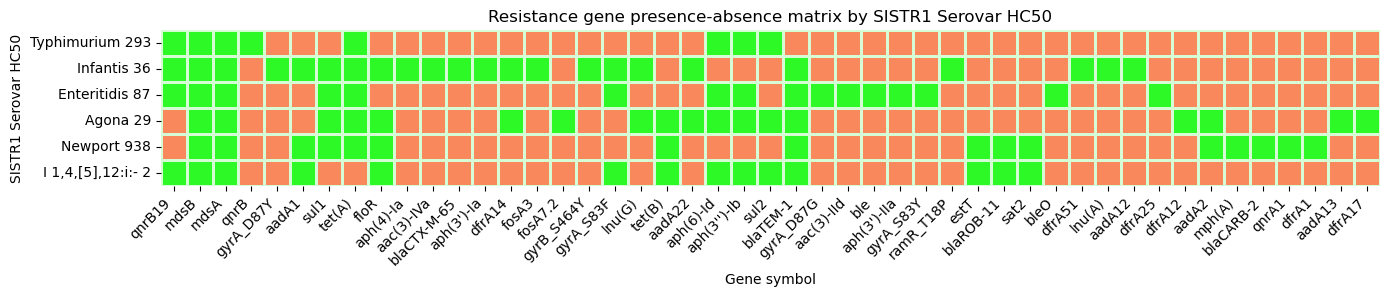

In [13]:
palette = sns.color_palette(["#f9895c", "#2cf925"])

plt.figure(figsize=(14, 12))
ax = sns.heatmap(matrix, cmap=palette, cbar=False, linewidths=1, linecolor='#d5fcd4', square=True)

plt.xticks(rotation=45, ha='right')
plt.title('Resistance gene presence-absence matrix by SISTR1 Serovar HC50')
plt.xlabel('Gene symbol')
plt.ylabel('SISTR1 Serovar HC50')

plt.tight_layout()
plt.savefig(f'img/HC50_AMR_resistance_gene_presence_absence_matrix.png', format='png', bbox_inches='tight')
plt.show()

### Histogram

In [14]:
def histogram_plot(column, name: str):
    plt.figure(figsize=(10, 6))
    sns.histplot(column, bins=5, kde=False, color='skyblue')

    plt.xticks(rotation=45, ha='right')
    plt.title(f'{name} frequency', fontsize=16)
    plt.xlabel(f'{name}', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'img/frequency_{name.replace(" ", "_").lower()}.png', format='png')
    plt.show()

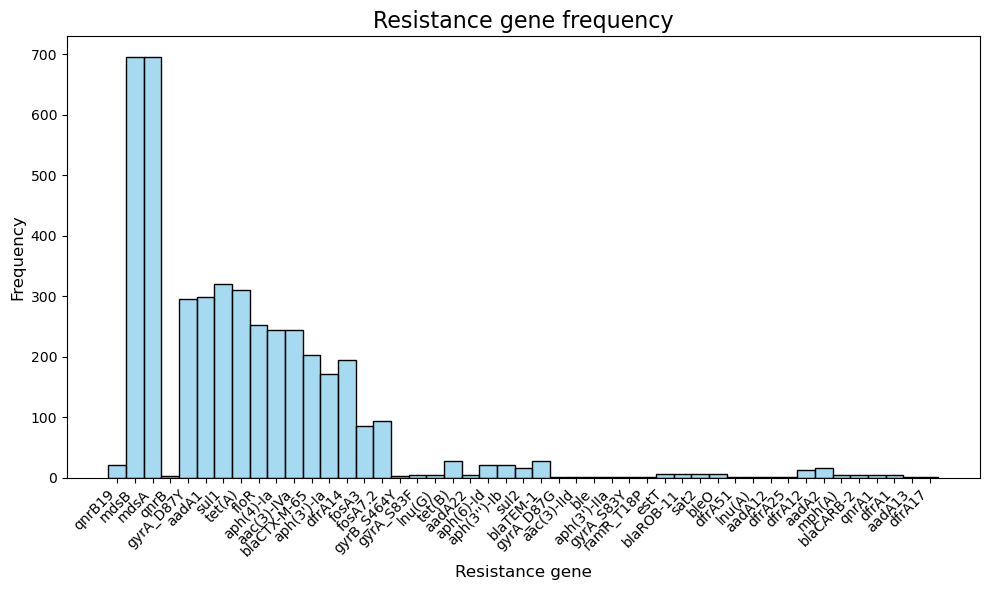

In [15]:
histogram_plot(df['Gene symbol'], "Resistance gene")

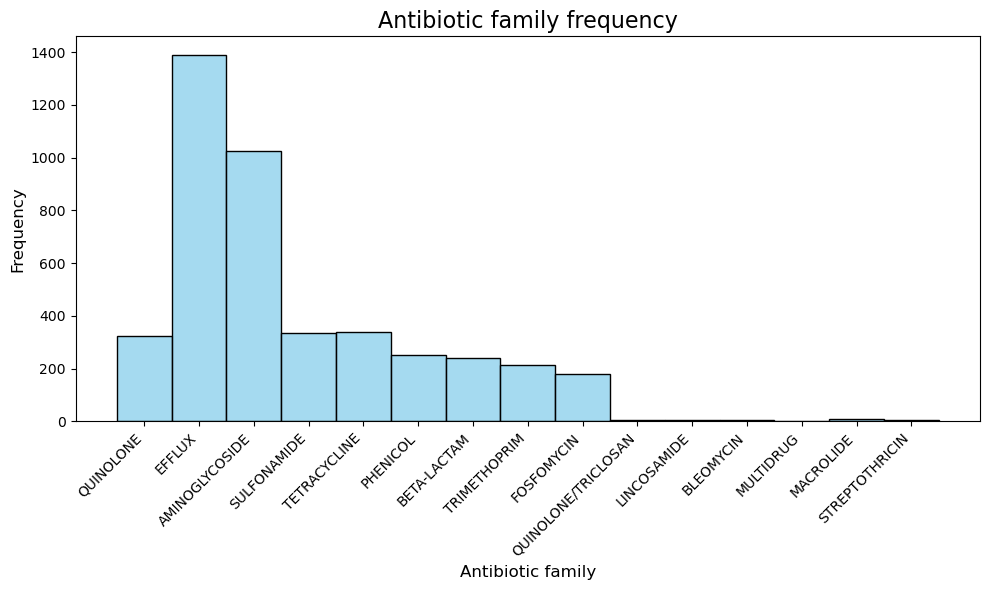

In [16]:
histogram_plot(df['Class'], 'Antibiotic family')